# 04 — Comparações: a estrutura de 4 sinais vale a pena?

Os três notebooks anteriores descrevem **um** detector. Este compara **arquiteturas
diferentes sobre exatamente o mesmo dado e a mesma régua**, para que a escolha pare
de ser opinião.

| | Sinais | Modelo | Task |
|---|---|---|---|
| **4 sinais** | 4 | 2 autoencoders (temperatura, pressão/óleo) + spread do mancal + z da selagem | `3841ddb9…` |
| **modelo único** | 1 | 1 autoencoder/PCA sobre os 26 sensores juntos | `e63d6a38…` |

**O que é idêntico nas duas** — e isso é o ponto: máscara de operação (`RUNNING_A ≥ 0,5`),
2 h de exclusão pós-partida, veto de sensor congelado, baseline das últimas 300/400 h
de operação estável, exclusão dos dias antes de cada falha e das janelas de alarme,
re-treino mensal (walk-forward), e a avaliação — 8 eventos, janela de 48 h, falso
positivo por episódio e por hora sobre o tempo de operação.

Muda **só a estrutura do score**. Então a diferença entre as duas mede uma coisa só.

> A pergunta prática: se o modelo único chegar perto, adotamos ele — resultado bom e
> fácil de explicar vale mais que resultado bom e difícil de defender. Se não chegar,
> este notebook é a justificativa da complexidade.

In [1]:
# ============================================================
TASKS = {
    "4 sinais": "3841ddb9430946c48cbecb5717e9f1ea",
    "modelo único": "e63d6a3828e743ed8be2f758ee493629",
}
TETO_FP = 1.0          # teto de falso positivo por mês
# ============================================================
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clearml import Task

from cabiunas_pdm import viz
viz.usar_estilo()
CORES = {"4 sinais": "#7b3294", "modelo único": "#008837"}

def carregar(tasks):
    """Puxa a grade de cada task. Task ainda rodando entra como None, sem quebrar."""
    saida = {}
    for nome, tid in tasks.items():
        tarefa = Task.get_task(task_id=tid)
        status = tarefa.get_status()
        if "automl_results" not in tarefa.artifacts:
            print(f"⏳ {nome}: task {tid[:8]} está '{status}' e ainda não publicou a "
                  f"grade — as figuras dela ficam de fora até terminar")
            saida[nome] = None
            continue
        grade = tarefa.artifacts["automl_results"].get()
        print(f"✓ {nome}: {len(grade):,} configurações | status={status}")
        saida[nome] = grade
    return saida

grades = carregar(TASKS)
disponiveis = {k: v for k, v in grades.items() if v is not None}

✓ 4 sinais: 20,736 configurações | status=completed


✓ modelo único: 6,912 configurações | status=completed


## 1. A fronteira das duas

Cada ponto é o **menor falso positivo possível** para aquele número de eventos
antecipados. Quanto mais para a esquerda e para cima, melhor. A linha vermelha é o
teto de 1 falso positivo por mês.

O painel da direita mostra a mesma coisa em **horas de alarme falso por mês** — que
é o que a operação sente. Um episódio de 10 min e um de uma semana contam igual na
métrica de episódios, e não são a mesma coisa no plantão.

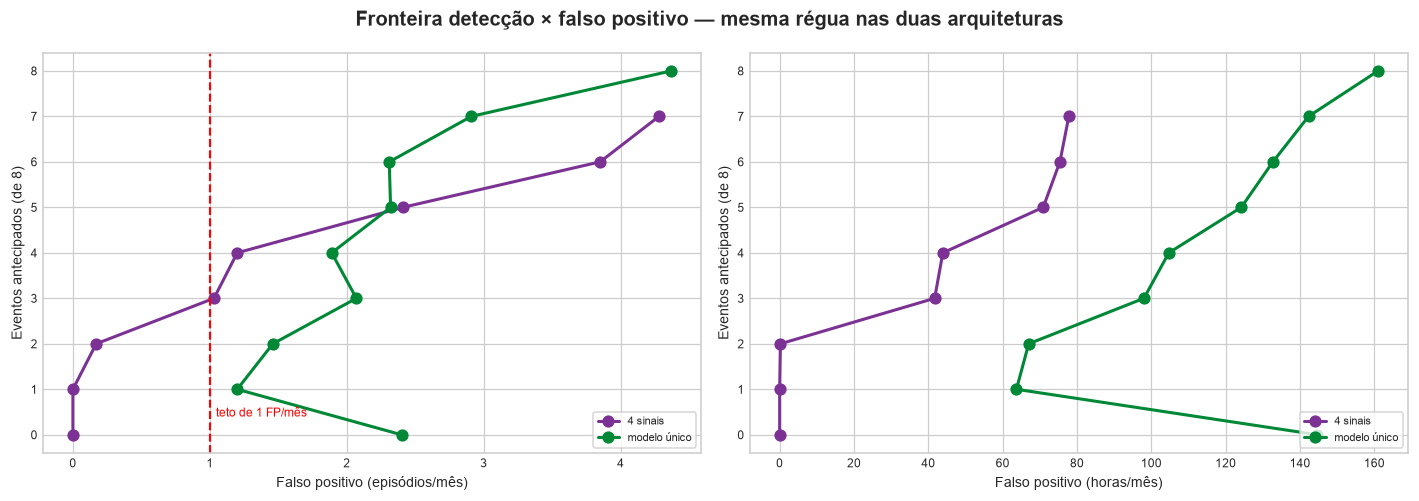

In [2]:
def fronteira(grade):
    return grade.groupby("eventos_detectados").agg(
        fp=("fp_por_mes", "min"), fp_h=("fp_horas_por_mes", "min"),
        lead=("lead_medio_h", "max"), n=("fp_por_mes", "size"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
for nome, grade in disponiveis.items():
    f = fronteira(grade)
    ax1.plot(f["fp"], f.index, marker="o", ms=7, lw=2, color=CORES[nome], label=nome)
    ax2.plot(f["fp_h"], f.index, marker="o", ms=7, lw=2, color=CORES[nome], label=nome)
for eixo, rotulo in ((ax1, "Falso positivo (episódios/mês)"),
                     (ax2, "Falso positivo (horas/mês)")):
    eixo.set_xlabel(rotulo); eixo.set_ylabel("Eventos antecipados (de 8)")
    eixo.legend(loc="lower right", frameon=True)
ax1.axvline(TETO_FP, color="red", ls="--", lw=1.4)
ax1.annotate("teto de 1 FP/mês", xy=(TETO_FP, 0.4), xytext=(4, 0),
             textcoords="offset points", fontsize=8, color="red")
fig.suptitle("Fronteira detecção × falso positivo — mesma régua nas duas arquiteturas",
             fontsize=13, fontweight="bold")
fig.tight_layout();

In [3]:
# a fronteira em números, com a diferença explícita
tabelas = {nome: fronteira(g)[["fp", "fp_h", "lead"]] for nome, g in disponiveis.items()}
comparativo = pd.concat(tabelas, axis=1).round(2)
comparativo.columns = pd.MultiIndex.from_tuples(
    [(a, {"fp": "FP/mês", "fp_h": "FP h/mês", "lead": "melhor lead h"}[b])
     for a, b in comparativo.columns])
comparativo

4 sinais                        modelo único           \
                     FP/mês FP h/mês melhor lead h       FP/mês FP h/mês   
eventos_detectados                                                         
0                      0.00      0.0           NaN         2.40    144.7   
1                      0.00      0.0          48.0         1.20     63.7   
2                      0.17      0.2          45.8         1.46     67.0   
3                      1.03     41.7          45.1         2.07     98.0   
4                      1.20     43.9          43.5         1.89    104.7   
5                      2.41     70.9          41.8         2.32    124.2   
6                      3.85     75.4          37.5         2.31    132.7   
7                      4.28     77.8          34.6         2.91    142.3   
8                       NaN      NaN           NaN         4.37    161.0   

                                  
                   melhor lead h  
eventos_detectados                
0                            NaN  
1                           47.5  
2                           39.5  
3                           42.0  
4                           38.1  
5                           40.1  
6                           37.2  
7                           36.2  
8                           35.0

## 2. O melhor ponto de cada uma

"Melhor" aqui é: **respeita o teto, antecipa o máximo de eventos e, entre os empates,
tem o menor número de horas de alarme falso.** É um critério diferente do que a busca
usa por conta própria (ela prioriza antecedência e por isso escolhe pontos com muito
mais falso positivo).

Se uma arquitetura **não tiver nenhuma configuração dentro do teto**, a tabela diz isso
em vez de escolher um ponto de fora e fingir que dá na mesma.

In [4]:
TCOLS = lambda g: [c for c in g.columns if c.startswith("trial.")]

def melhor_no_teto(grade, teto=TETO_FP):
    """Melhor ponto que respeita o teto E antecipa algo. None se não existir."""
    dentro = grade[(grade["fp_por_mes"] <= teto) & (grade["eventos_detectados"] > 0)]
    if dentro.empty:
        return None
    return dentro.sort_values(["eventos_detectados", "fp_horas_por_mes", "fp_por_mes"],
                              ascending=[False, True, True]).iloc[0]

def melhor_livre(grade):
    """Melhor ponto ignorando o teto: máxima detecção, depois menos horas de FP."""
    return grade.sort_values(["eventos_detectados", "fp_horas_por_mes"],
                             ascending=[False, True]).iloc[0]

def resumo(r, grade):
    if r is None:
        return {"eventos": "— nenhuma configuração dentro do teto —"}
    return {"eventos": f"{int(r['eventos_detectados'])}/8",
            "antecedência média (h)": r["lead_medio_h"],
            "FP/mês": r["fp_por_mes"], "FP horas/mês": r["fp_horas_por_mes"],
            "episódios totais": int(r["episodios_totais"]),
            "config": " | ".join(f"{c.replace('trial.','')}={r[c]}" for c in TCOLS(grade))}

print("configurações que respeitam o teto de", TETO_FP, "FP/mês:")
for nome, g in disponiveis.items():
    print(f"  {nome:14s}: {int((g['fp_por_mes'] <= TETO_FP).sum()):>6,} de {len(g):>6,}"
          f"  | menor FP alcançável: {g['fp_por_mes'].min():.2f}/mês")
print()
pd.DataFrame({f"{nome} — dentro do teto": resumo(melhor_no_teto(g), g)
              for nome, g in disponiveis.items()}
             | {f"{nome} — sem teto": resumo(melhor_livre(g), g)
                for nome, g in disponiveis.items()})

configurações que respeitam o teto de 1.0 FP/mês:
  4 sinais      :  4,047 de 20,736  | menor FP alcançável: 0.00/mês
  modelo único  :      0 de  6,912  | menor FP alcançável: 1.20/mês



,4 sinais — dentro do teto,modelo único — dentro do teto,4 sinais — sem teto,modelo único — sem teto
eventos,2/8,— nenhuma configuração dentro do teto —,7/8,8/8
antecedência média (h),23.4,NaN,26.6,29.4
FP/mês,0.26,NaN,5.16,8.52
FP horas/mês,0.2,NaN,77.8,161.0
episódios totais,8,NaN,78,128
config,model=ae | grid=30s | baseline_hours=400 | ewm...,NaN,model=iforest | grid=30s | baseline_hours=400 ...,model=ae | grid=30s | baseline_hours=400 | ewm...


## 3. A comparação em pé de igualdade

A tabela acima compara os pontos preferidos de cada arquitetura, que caem em regimes
diferentes — e isso engana. A comparação honesta é fixar o **orçamento de falso
positivo** e perguntar quantas falhas cada uma antecipa com ele.

É essa tabela que responde a pergunta do notebook.

,4 sinais — eventos de 8,modelo único — eventos de 8
orçamento (FP/mês),,
0.5,2,0
1.0,2,0
1.5,4,2
2.5,5,6
4.0,6,7
6.0,7,8


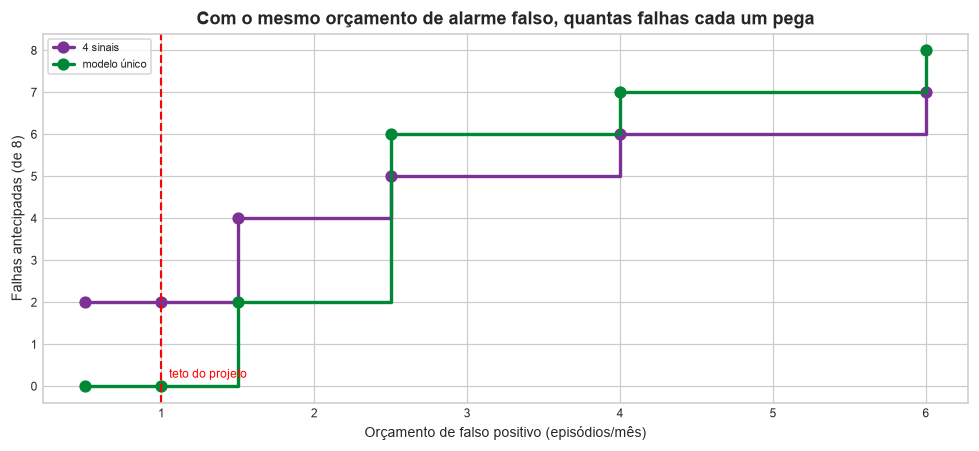

In [5]:
ORCAMENTOS = [0.5, 1.0, 1.5, 2.5, 4.0, 6.0]

linhas = []
for teto in ORCAMENTOS:
    linha = {"orçamento (FP/mês)": teto}
    for nome, g in disponiveis.items():
        sub = g[g["fp_por_mes"] <= teto]
        linha[nome] = int(sub["eventos_detectados"].max()) if len(sub) else 0
    linhas.append(linha)
orcamento = pd.DataFrame(linhas).set_index("orçamento (FP/mês)")
orcamento.columns = [f"{c} — eventos de 8" for c in orcamento.columns]

fig, ax = plt.subplots(figsize=(9, 4.2))
for nome in disponiveis:
    ax.step(orcamento.index, orcamento[f"{nome} — eventos de 8"], where="post",
            marker="o", ms=7, lw=2.2, color=CORES[nome], label=nome)
ax.axvline(TETO_FP, color="red", ls="--", lw=1.4)
ax.annotate("teto do projeto", xy=(TETO_FP, 0.2), xytext=(5, 0),
            textcoords="offset points", fontsize=8, color="red")
ax.set_xlabel("Orçamento de falso positivo (episódios/mês)")
ax.set_ylabel("Falhas antecipadas (de 8)")
ax.set_yticks(range(0, 9))
ax.legend(frameon=True)
ax.set_title("Com o mesmo orçamento de alarme falso, quantas falhas cada um pega",
             fontweight="bold", fontsize=12)
fig.tight_layout()
orcamento

## 4. Quem antecipa qual falha

Fixando o **mesmo número de eventos** nas duas, quais falhas cada uma pega — e isso muda a leitura. Uma que pega a falha de 29/04/2025 (23 dias de
máquina parada) vale mais que uma que pega uma parada de 4 h, mesmo empatando na
contagem.

In [6]:
def leads_do_ponto(grade, r):
    return {c.replace("leads.", "")[:16]: r[c]
            for c in grade.columns if c.startswith("leads.") and pd.notna(r[c])}

# compara no MESMO nível de detecção (4 de 8) — comparar os pontos preferidos de
# cada um não diz nada, porque eles caem em regimes diferentes
NIVEL = 4
colunas = {}
for nome, g in disponiveis.items():
    sub = g[g["eventos_detectados"] == NIVEL]
    if sub.empty:
        continue
    r = sub.sort_values("fp_por_mes").iloc[0]
    colunas[f"{nome}\n({r['fp_por_mes']} FP/mês)"] = leads_do_ponto(g, r)
matriz = pd.DataFrame(colunas)
matriz = matriz.reindex(sorted(matriz.index)).round(1)
matriz.index.name = f"falha (antecedência em h, no ponto de {NIVEL}/8)"
matriz

,4 sinais\n(1.2 FP/mês),modelo único\n(1.89 FP/mês)
"falha (antecedência em h, no ponto de 4/8)",,
2025-03-17 18:16,29.3,NaN
2025-04-07 21:18,45.6,30.6
2025-04-11 17:04,3.8,25.5
2025-04-29 03:04,NaN,32.2
2026-02-26 15:34,18.4,15.9


## 5. Como cada um se comporta ao longo da série

As duas arquiteturas no **mesmo nível de detecção (4 de 8 falhas)**, sobre os 16 meses.
É aqui que a diferença de falso positivo deixa de ser número e fica visível: o que
importa não é onde cada um acerta, é **quanto tempo cada um passa gritando**.

Em cada figura: um painel por sinal (roxo = score, vermelho tracejado = limite do mês,
área vermelha = acima do limite), e embaixo a contagem de sinais sustentados com os
episódios marcados — triângulo vermelho quando antecipou falha, cinza quando é falso
positivo.

In [7]:
from cabiunas_pdm.replay import DetectionReplay

# configurações no ponto de 4/8 eventos, colhidas da própria grade de cada task
PONTOS = {}
for nome, g in disponiveis.items():
    sub = g[g["eventos_detectados"] == 4]
    if sub.empty:
        continue
    r = sub.sort_values("fp_por_mes").iloc[0]
    PONTOS[nome] = {c.replace("trial.", ""): (r[c].item() if hasattr(r[c], "item") else r[c])
                    for c in TCOLS(g)}
for nome, cfg in PONTOS.items():
    print(f"{nome}: {cfg}")

4 sinais: {'model': 'pca', 'grid': '30s', 'baseline_hours': 400, 'ewma': '30min', 'exclude_days': 0, 'exclude_alarm_h': 1.0, 'threshold': 99.9, 'sustain': '2h', 'confirm': 3, 'min_alert': '0min'}
modelo único: {'model': 'pca', 'grid': '30s', 'baseline_hours': 300, 'ewma': '30min', 'exclude_days': 0, 'exclude_alarm_h': 0.0, 'threshold': 99.99, 'sustain': '4h', 'confirm': 1, 'min_alert': '30min'}


[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] ajustando pca walk-forward (grade 30s, baseline 400 h, exclui 0d + 1.0h de alarme)...


[veto] pressao_oleo: ['954005_624_PI_0319'] são constantes por natureza (11.8%) e ficam fora do teste


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] ajustando pca walk-forward (grade 30s, baseline 300 h, exclui 0d + 0.0h de alarme)...


[veto] tudo: ['954005_624_PI_0319'] são constantes por natureza (11.8%) e ficam fora do teste


[replay] pca|30s|b300h|excl0d|alm0.0h|ewma30min|q99.99|sust4h|conf1|min30min -> 4/8 eventos | lead 26.1 h | FP 1.89/mês


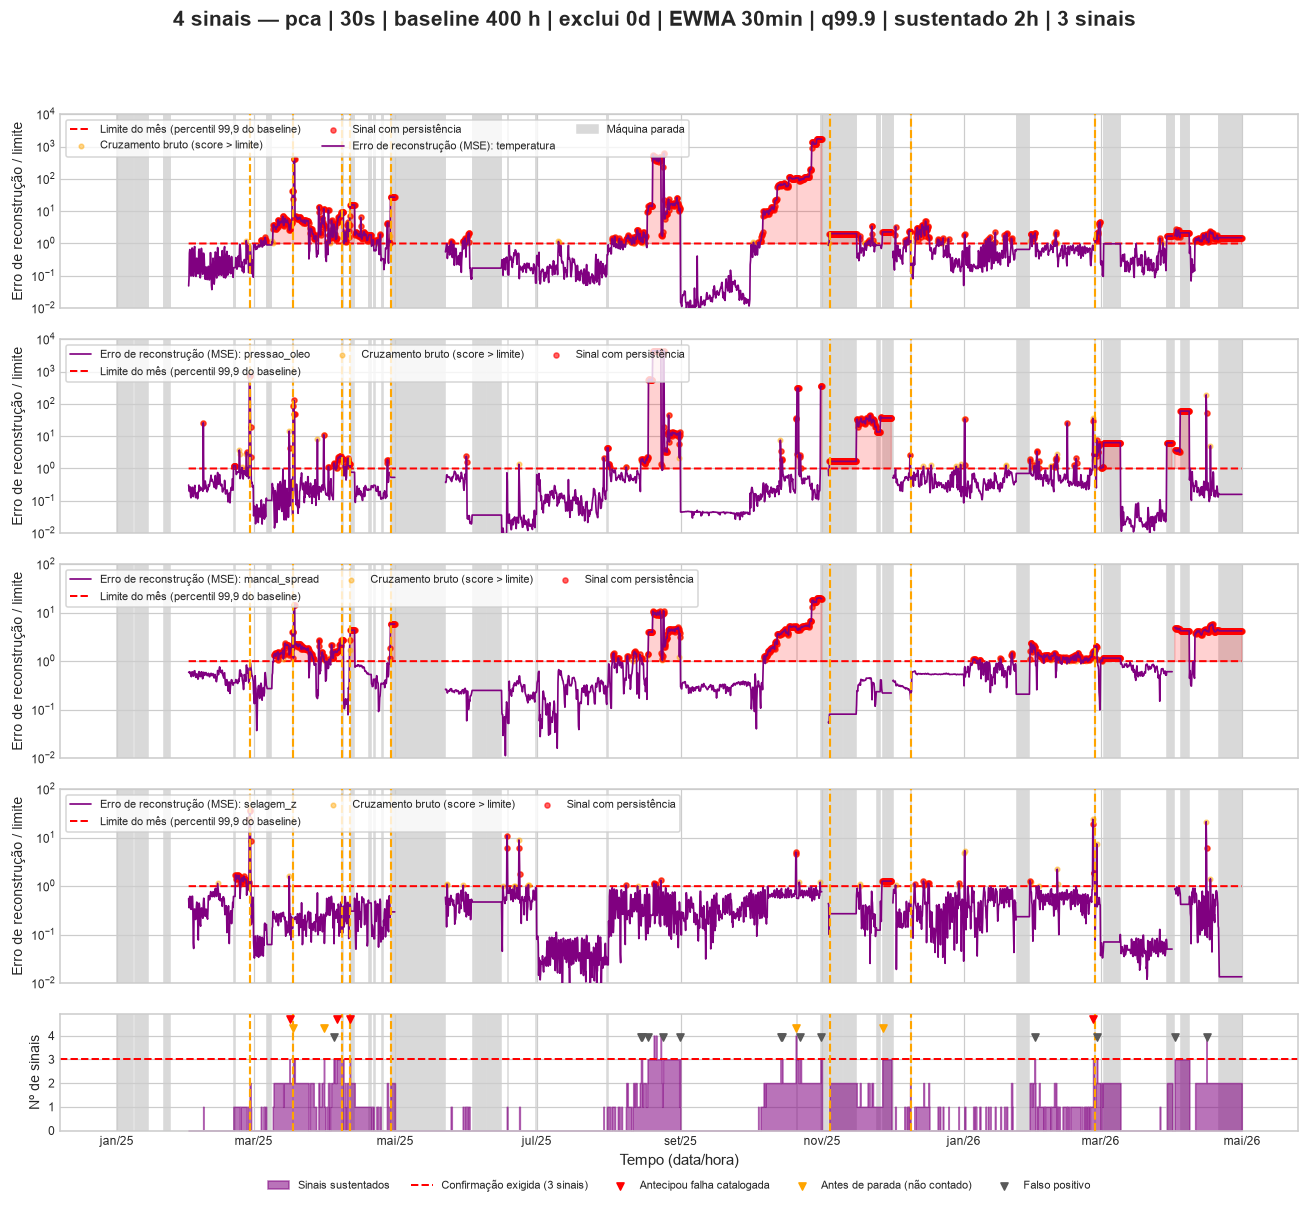

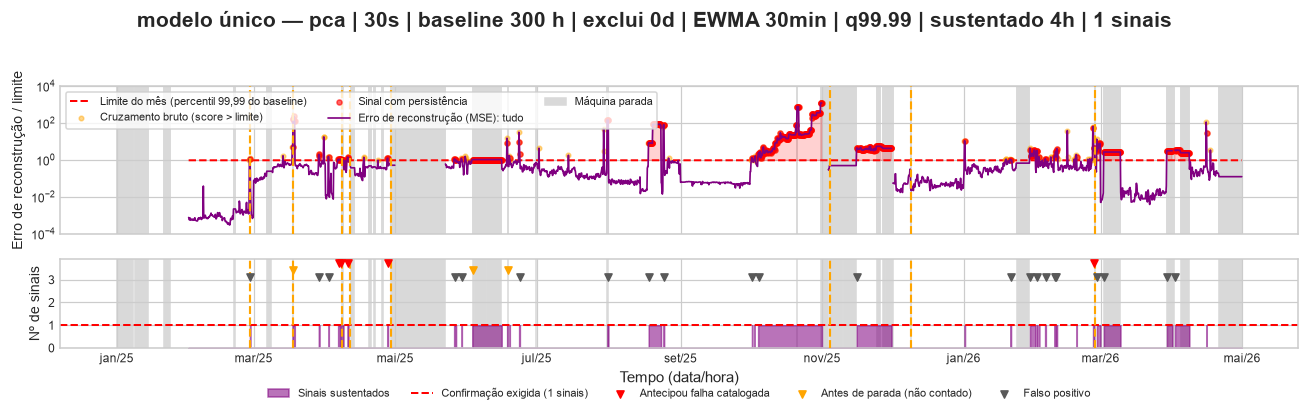

In [8]:
resultados = {}
for nome, cfg in PONTOS.items():
    replay = DetectionReplay(max_fp_per_month=TETO_FP,
                            single_model=(nome == "modelo único"))
    resultados[nome] = replay.run(**cfg)

for nome, res in resultados.items():
    fig = viz.plot_periodo(res, titulo=f"{nome} — {res.label()}")
    viz.salvar(fig, f"deteccao/comparacao_{nome.replace(' ', '_')}_periodo.png")

In [9]:
pd.DataFrame({nome: {
    "eventos": f"{r.metrics['eventos_detectados']}/8",
    "antecedência média (h)": r.metrics["lead_medio_h"],
    "FP/mês": r.metrics["fp_por_mes"],
    "FP horas/mês": r.metrics["fp_horas_por_mes"],
    "episódios no período": r.metrics["episodios_totais"],
    "% do tempo em operação sob alerta":
        f"{r.alert[r.scores.iloc[:, 0].notna()].mean():.2%}",
} for nome, r in resultados.items()})

,4 sinais,modelo único
eventos,4/8,4/8
antecedência média (h),24.3,26.1
FP/mês,1.2,1.89
FP horas/mês,43.9,142.4
episódios no período,22,30
% do tempo em operação sob alerta,7.01%,19.78%


## 6. Veredito

In [10]:
if len(disponiveis) < 2:
    print("Aguardando a segunda task. Re-execute este notebook quando ela terminar.")
else:
    a, b = "4 sinais", "modelo único"
    ga, gb = disponiveis[a], disponiveis[b]
    print(f"{'orçamento':>12s} | {a:>12s} | {b:>12s}")
    for teto in [TETO_FP, 2.5, 6.0]:
        da = ga[ga["fp_por_mes"] <= teto]["eventos_detectados"].max() if len(ga[ga["fp_por_mes"] <= teto]) else 0
        db = gb[gb["fp_por_mes"] <= teto]["eventos_detectados"].max() if len(gb[gb["fp_por_mes"] <= teto]) else 0
        print(f"{teto:>10} /mês | {int(da):>10}/8 | {int(db):>10}/8")
    print()
    piso_a, piso_b = ga["fp_por_mes"].min(), gb["fp_por_mes"].min()
    print(f"menor falso positivo que cada arquitetura ALCANÇA: "
          f"{a} = {piso_a:.2f}/mês | {b} = {piso_b:.2f}/mês")
    print()
    if piso_b > TETO_FP >= piso_a:
        print(f"→ O MODELO ÚNICO NÃO CHEGA AO TETO DO PROJETO. O piso dele é "
              f"{piso_b:.2f} FP/mês;")
        print(f"  nenhuma das {len(gb):,} configurações fica abaixo de 1/mês. A estrutura")
        print("  de 4 sinais é o que torna o detector silencioso — é aí que ela se paga.")
        print()
        print("  Em contrapartida, no regime sensível o modelo único vai mais longe:")
        alto_b = gb["eventos_detectados"].max(); alto_a = ga["eventos_detectados"].max()
        print(f"  antecipa até {int(alto_b)}/8 falhas contra {int(alto_a)}/8 do outro.")
        print("  Ou seja: não é 'um é melhor', é cada um serve a um regime diferente.")
    elif piso_b <= TETO_FP:
        print("→ As duas alcançam o teto. Comparar pela tabela de orçamento acima.")

   orçamento |     4 sinais | modelo único
       1.0 /mês |          2/8 |          0/8
       2.5 /mês |          5/8 |          6/8
       6.0 /mês |          7/8 |          8/8

menor falso positivo que cada arquitetura ALCANÇA: 4 sinais = 0.00/mês | modelo único = 1.20/mês

→ O MODELO ÚNICO NÃO CHEGA AO TETO DO PROJETO. O piso dele é 1.20 FP/mês;
  nenhuma das 6,912 configurações fica abaixo de 1/mês. A estrutura
  de 4 sinais é o que torna o detector silencioso — é aí que ela se paga.

  Em contrapartida, no regime sensível o modelo único vai mais longe:
  antecipa até 8/8 falhas contra 7/8 do outro.
  Ou seja: não é 'um é melhor', é cada um serve a um regime diferente.


### Como ler o resultado sem se enganar

Três ressalvas que valem para qualquer conclusão desta página:

1. **São 8 eventos.** A diferença de um evento entre as duas arquiteturas é, em
   estatística, quase nada. Por isso a coluna de **horas de falso positivo** importa
   tanto quanto a de detecção: ela é medida sobre 348 dias, não sobre 8 pontos.
2. **A grade do modelo único é 3× menor** (6.912 contra 20.736), porque sem
   confirmação não existe aquela dimensão. Ele tem menos chances de sortear um ponto
   bom — mas também menos risco de se ajustar à grade.
3. **Nenhuma das duas foi validada fora deste período.** As duas veem os mesmos 8
   eventos e o mesmo ano e meio. A validação secundária nos 420 alarmes de aviso em
   operação, que dá poder estatístico de verdade, é o passo seguinte e ainda não está
   feita.

Quando o modelo da Lara entrar na comparação, ele vira uma terceira coluna aqui —
pegando o `best_scores` da task dela e passando por esta mesma régua.